In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten


# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load data
file_path = "Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_5024_Alipur_Delhi_DPCC_15Min.csv"
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')


       PM2.5 (µg/m³)  PM10 (µg/m³)    NO (µg/m³)   NO2 (µg/m³)     NOx (ppb)  \
count   28224.000000  28224.000000  28224.000000  28224.000000  26653.000000   
mean       71.565866    164.500319      5.189204     26.375935     17.956538   
std        59.870873    110.509145     12.594078     17.771561     16.351019   
min         1.000000      1.000000      0.100000      0.100000      0.000000   
25%        29.000000     81.000000      1.400000     14.600000      9.200000   
50%        51.000000    144.000000      2.200000     22.000000     13.200000   
75%        97.000000    224.000000      3.300000     33.300000     20.600000   
max       454.000000    809.000000    383.300000    163.400000    236.100000   

        NH3 (µg/m³)   SO2 (µg/m³)    CO (mg/m³)  Ozone (µg/m³)  \
count  26070.000000  28224.000000  28224.000000   28224.000000   
mean      27.146924     11.307223      0.876210      45.383879   
std       11.977562      9.828932      0.402729      48.035583   
min        0.10

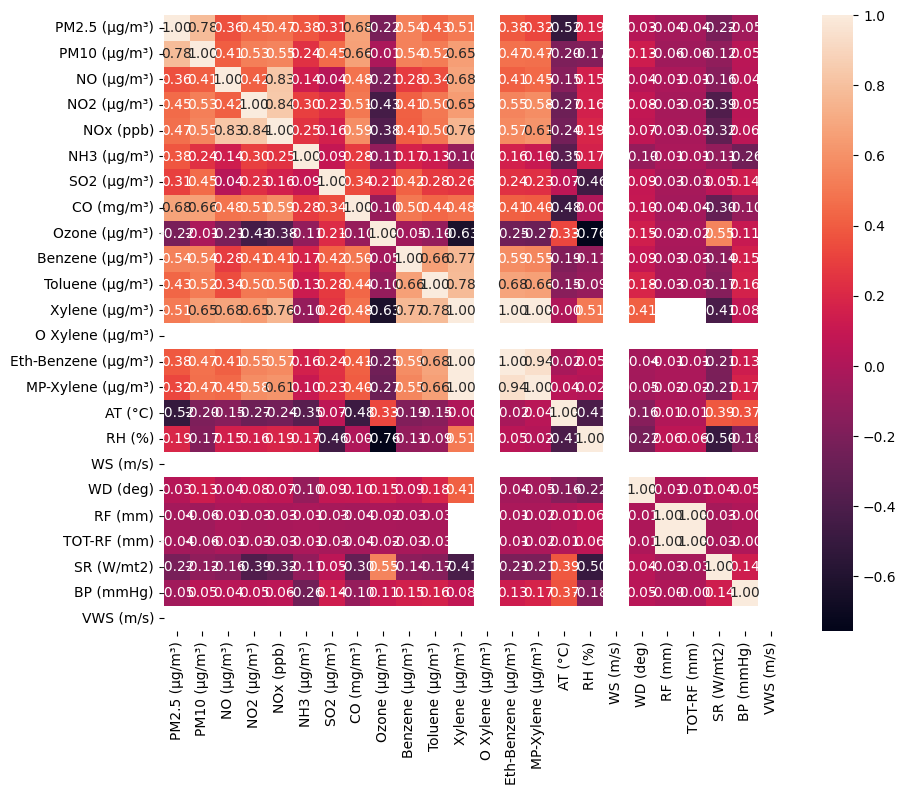

In [10]:

# Basic statistics
print(data.describe())

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f")
plt.show()


       PM2.5 (µg/m³)  PM10 (µg/m³)    NO (µg/m³)   NO2 (µg/m³)   SO2 (µg/m³)  \
count   28224.000000  28224.000000  28224.000000  28224.000000  28224.000000   
mean       71.565866    164.500319      5.189204     26.375935     11.307223   
std        59.870873    110.509145     12.594078     17.771561      9.828932   
min         1.000000      1.000000      0.100000      0.100000      0.100000   
25%        29.000000     81.000000      1.400000     14.600000      5.700000   
50%        51.000000    144.000000      2.200000     22.000000      8.300000   
75%        97.000000    224.000000      3.300000     33.300000     14.000000   
max       454.000000    809.000000    383.300000    163.400000    198.100000   

         CO (mg/m³)  Ozone (µg/m³)  
count  28224.000000   28224.000000  
mean       0.876210      45.383879  
std        0.402729      48.035583  
min        0.000000       0.100000  
25%        0.630000       8.300000  
50%        0.850000      25.600000  
75%        1.080000 

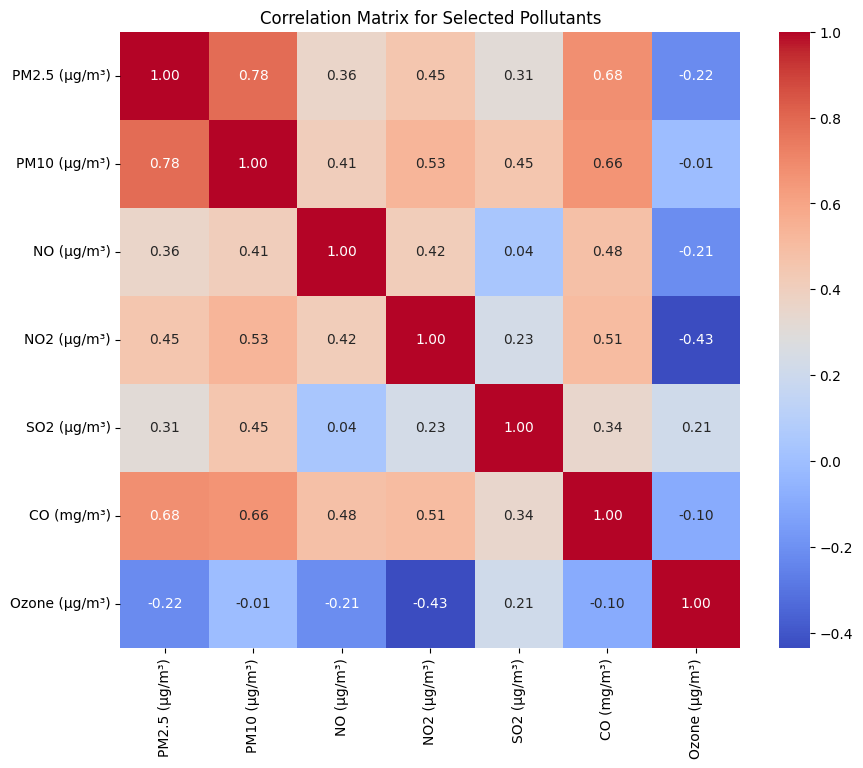

In [5]:
pollutants = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 
    'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 
    'Ozone (µg/m³)'
]

# Focus on selected pollutants for correlation analysis
data_selected = data[pollutants]

# Basic statistics
print(data_selected.describe())

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_selected.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix for Selected Pollutants')
plt.show()

### model 1 step 1

In [15]:

# Function to create sequences
def create_sequences(data, n_steps):
    X, y = [], []
    data = np.expand_dims(data, axis=1)  # Ensure data has at least two dimensions [samples, features]
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps, :])  # Slice keeping the features dimension
        y.append(data[i + n_steps, 0])  # Assuming the target is the first feature
    return np.array(X), np.array(y)

# Hyperparameters
n_steps = 4  # Using 4 time steps per sequence

# Preparing data for each pollutant
model_data = {}
for pollutant in pollutants:
    X, y = create_sequences(data[pollutant].values, n_steps)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    model_data[pollutant] = (X_train, X_test, y_train, y_test)


In [ ]:
# def build_model(input_shape, lstm_units, dense_units, dropout_rate, learning_rate):
#     model = Sequential([
#         LSTM(lstm_units, input_shape=input_shape, return_sequences=True),
#         Dropout(dropout_rate),
#         LSTM(lstm_units // 2),
#         Dropout(dropout_rate),
#         Dense(dense_units, activation='relu'),
#         Dense(1)
#     ])
#     optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#     model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
#     return model

# # Defining a more extensive range of hyperparameters
# lstm_units_options = [32]
# dense_units_options = [32]
# dropout_rate_options = [0.1]
# learning_rate_options = [0.001]

# # Training loop for hyperparameter tuning
# results = []
# # Adjusted training loop for hyperparameter tuning
# for pollutant, data_tuple in model_data.items():
#     X_train, X_test, y_train, y_test = data_tuple
#     # X_train.shape should now be [samples, timesteps, features]
#     input_shape = (X_train.shape[1], X_train.shape[2])  # timesteps, features

#     for lstm_units in lstm_units_options:
#         for dense_units in dense_units_options:
#             for dropout_rate in dropout_rate_options:
#                 for learning_rate in learning_rate_options:
#                     model = build_model(input_shape, lstm_units, dense_units, dropout_rate, learning_rate)
#                     model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=0)
#                     mse, mae = model.evaluate(X_test, y_test, verbose=0)
#                     results.append({
#                         'Pollutant': pollutant,
#                         'LSTM Units': lstm_units,
#                         'Dense Units': dense_units,
#                         'Dropout Rate': dropout_rate,
#                         'Learning Rate': learning_rate,
#                         'MSE': mse,
#                         'MAE': mae
#                     })

# # Converting results to DataFrame for easier analysis
# results_df = pd.DataFrame(results)
# print(results_df)


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Assuming results_df is your DataFrame from the previous step
results_df = pd.DataFrame(results)

# Finding the best configuration for each pollutant based on MSE
best_configs = results_df.loc[results_df.groupby('Pollutant')['MSE'].idxmin()]

# Display the best configurations
print(best_configs[['Pollutant', 'LSTM Units', 'Dense Units', 'Dropout Rate', 'Learning Rate', 'MSE', 'MAE']])
